In [1]:
import os, json, gc
from collections import OrderedDict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io as sio

from tqdm.notebook import tqdm

from sklearn.model_selection import KFold, train_test_split, StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")
from src.preprocess import EmgEncoder
from src.model import ResNet1d

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# データの前処理

In [4]:
num_emg_channels = 16
num_axis = 3
input_length = 1000
output_length = 30
split_width = input_length // output_length

train = sio.loadmat("../data/train.mat")
test = sio.loadmat("../data/test.mat")

X = []
y = []
test_X = []

# ユーザーごとに前処理を行う
users = ["0001", "0002", "0003", "0004"]
input_scalers = {}
output_scalers = {}
for user in users:
    train_x = train[user][0][0][0]
    train_y = train[user][0][0][1]
    test_x = test[user][0][0][0]
    
    # EMGのチャンネルごとに正規化
    input_scaler = {}
    for channel_id in range(num_emg_channels):
        _max = np.max(train_x[:, channel_id, :])
        _min = np.min(train_x[:, channel_id, :])
        train_x[:, channel_id, :] = (train_x[:, channel_id, :] - _min) / (_max - _min)
        test_x[:, channel_id, :] = (test_x[:, channel_id, :] - _min) / (_max - _min)
        input_scaler[channel_id] = (_min, _max)
    input_scalers[user] = input_scaler
    
    # 加速度の軸ごとに正規化
    output_scaler = {}
    for axis in range(num_axis):
        _max = np.max(train_y[:, axis, :])
        _min = np.min(train_y[:, axis, :])
        train_y[:, axis, :] = (train_y[:, axis, :] - _min) / (_max - _min)
        output_scaler[axis] = (_min, _max)
    output_scalers[user] = output_scaler
    
    # 入出力を分割して保存
    trial_x = []
    trial_y = []
    trial_test_x = []
    for _x, _y, _x_test in zip(train_x, train_y, test_x):
        _x = np.array_split(_x[:, :990], 30, axis=1)
        _y = np.split(_y, 30, axis=1)
        _x_test = np.array_split(_x_test[:, :990], 30, axis=1)
        
        trial_x += _x
        trial_y += _y
        trial_test_x += _x_test
    X += trial_x
    y += trial_y
    test_X += trial_test_x


X = np.array(X)
y = np.array(y)
test_X = np.array(test_X)

X.shape, y.shape, test_X.shape

((37770, 16, 33), (37770, 3, 1), (37770, 16, 33))

# データセットの作成

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, x, y=None, v_axis: int=0):
        self.x = x
        self.y = y
        self.v_axis = v_axis
    
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        if self.y is None:
            return torch.tensor(self.x[idx], dtype=torch.float32)
        
        return torch.tensor(self.x[idx], dtype=torch.float32), torch.tensor(self.y[idx, self.v_axis, :], dtype=torch.float32)

dataset = CustomDataset(X, y)
test_dataset = CustomDataset(test_x)

sample_x, sample_y = next(iter(dataset))
sample_x.shape, sample_y.shape

(torch.Size([16, 33]), torch.Size([1]))

# モデルの定義

Layer (type:depth-idx)                   Output Shape              Param #
ResNet_v2                                [1, 1]                    --
├─Conv1d: 1-1                            [1, 32, 17]               3,616
├─BatchNorm1d: 1-2                       [1, 32, 17]               64
├─ReLU: 1-3                              [1, 32, 17]               --
├─MaxPool1d: 1-4                         [1, 32, 9]                --
├─Sequential: 1-5                        [1, 64, 9]                --
│    └─ResBlock_v2: 2-1                  [1, 64, 9]                --
│    │    └─Conv1d: 3-1                  [1, 64, 9]                6,208
│    │    └─BatchNorm1d: 3-2             [1, 64, 9]                128
│    │    └─ReLU: 3-3                    [1, 64, 9]                --
│    │    └─Conv1d: 3-4                  [1, 64, 9]                12,352
│    │    └─BatchNorm1d: 3-5             [1, 64, 9]                128
│    │    └─ReLU: 3-6                    [1, 64, 9]                --
│  

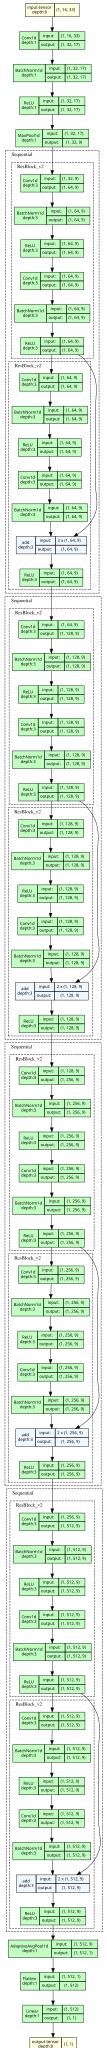

In [6]:
class ResBlock_v2(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu2 = nn.ReLU()
        
    def forward(self, x):
        h = self.conv1(x)
        h = self.bn1(h)
        h = self.relu1(h)
        h = self.conv2(h)
        h = self.bn2(h)
        
        if self.in_channels != self.out_channels:
            return self.relu2(h)

        return self.relu2(x + h)

class ResNet_v2(nn.Module):
    def __init__(self, in_channels, out_channels, first_out_channels=32, num_layers=[2, 2, 2, 2]):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.first_out_channels = first_out_channels
        self.num_layers = num_layers
        self.hidden_state = [first_out_channels*(2**(i+1)) for i in range(4)]
        
        self.conv1 = nn.Conv1d(in_channels, first_out_channels, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm1d(first_out_channels)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)
        self.block1 = self._build_block(first_out_channels, self.hidden_state[0], num_layers[0])
        self.block2 = self._build_block(self.hidden_state[0], self.hidden_state[1], num_layers[0])
        self.block3 = self._build_block(self.hidden_state[1], self.hidden_state[2], num_layers[0])
        self.block4 = self._build_block(self.hidden_state[2], self.hidden_state[3], num_layers[0])
        
        # self.blocks = [
        #     self._build_block(
        #         in_channels  = ((i)*first_out_channels)**2,
        #         out_channels = ((i+1)*first_out_channels)**2,
        #         num_layer    = num_layer
        #     ) for i, num_layer in enumerate(num_layers)
        # ]
        self.pool2 = nn.AdaptiveAvgPool1d(output_size=out_channels)
        self.flatten = nn.Flatten()
        self.liear = nn.Linear(32*in_channels, 1)
        
    def forward(self, x):
        h = self.conv1(x)
        h = self.bn1(h)
        h = self.relu1(h)
        h = self.pool1(h)
        # for block in self.blocks:
        #     h = block(h)
        h = self.block1(h)
        h = self.block2(h)
        h = self.block3(h)
        h = self.block4(h)
        h = self.pool2(h)
        h = self.flatten(h)
        h = self.liear(h)

        return h
    
    def _build_block(self, in_channels, out_channels, num_layer: int=2):
        block = nn.Sequential(
            ResBlock_v2(in_channels, out_channels)
        )
        for _ in range(num_layer - 1):
            block.append(
                ResBlock_v2(out_channels, out_channels)
            )
        return block

from torchview import draw_graph
from torchinfo import summary

model = ResNet_v2(16, 1)
print(summary(model, input_size=(1, 16, 33)))
model_graph = draw_graph(model, input_size=(1, 16, 33), expand_nested=True)
model_graph.visual_graph

# モデルの学習

In [7]:
def build_model(learning_rate):
    model = ResNet_v2(16, 1)
    loss_function = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    return model, loss_function, optimizer

def train_1epoch(model, loss_fn, optimizer, train_loader):
    total_loss = 0
    for i, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    return total_loss / len(train_loader)

def valid_1epoch(model, loss_fn, valid_loader):
    total_loss = 0
    with torch.no_grad():
        for i, (x, y) in enumerate(valid_loader):
            x = x.to(device)
            y = y.to(device)
            pred = model(x)
            total_loss += loss_fn(pred, y).item()
        
    return total_loss / len(valid_loader)

## Stratified KFold
- 各Foldにユーザーの偏りがないように調整

In [8]:
# ユーザーを分類するようなダミー目的変数を作成
num_trials = [len(train[user][0][0][0]) for user in users]
dummy_y = np.concat([np.zeros(trial*30)+i for i, trial in enumerate(num_trials)])
dummy_y, dummy_y.shape

(array([0., 0., 0., ..., 3., 3., 3.]), (37770,))

Axis 0, Fold 0:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/100 [00:00<?, ?it/s]

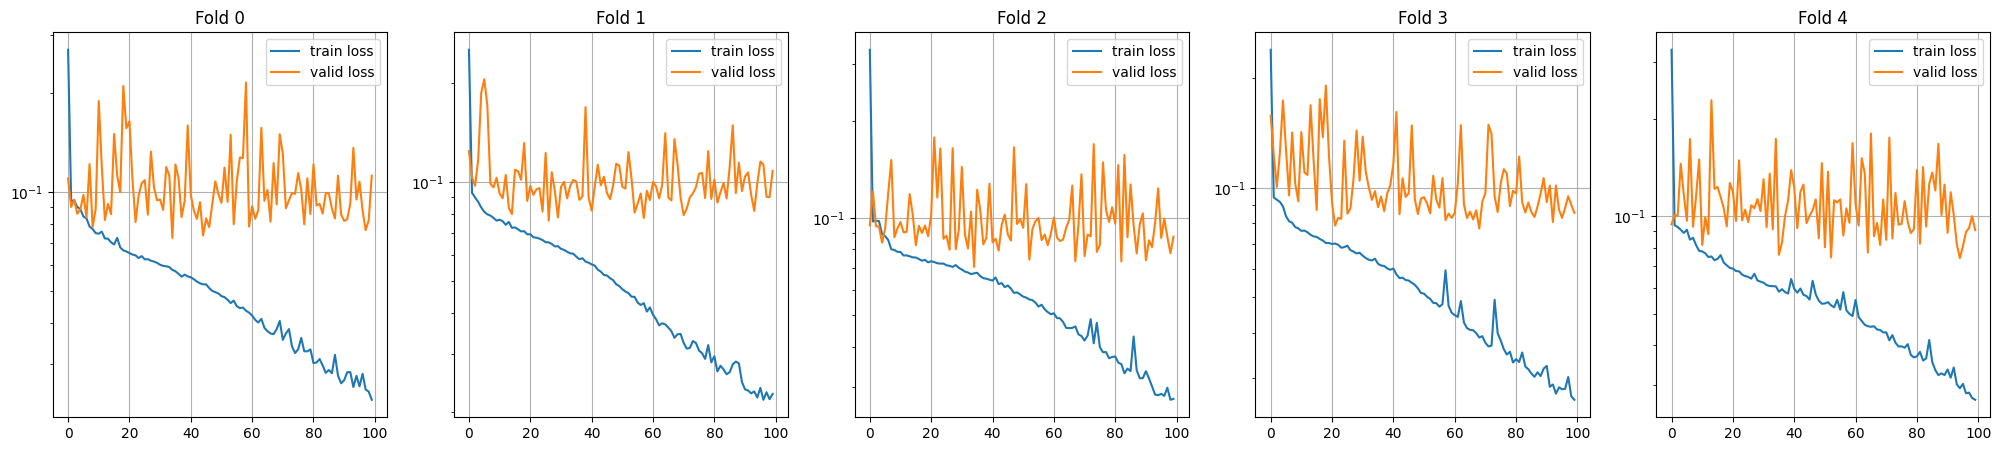

Axis 1, Fold 0:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/100 [00:00<?, ?it/s]

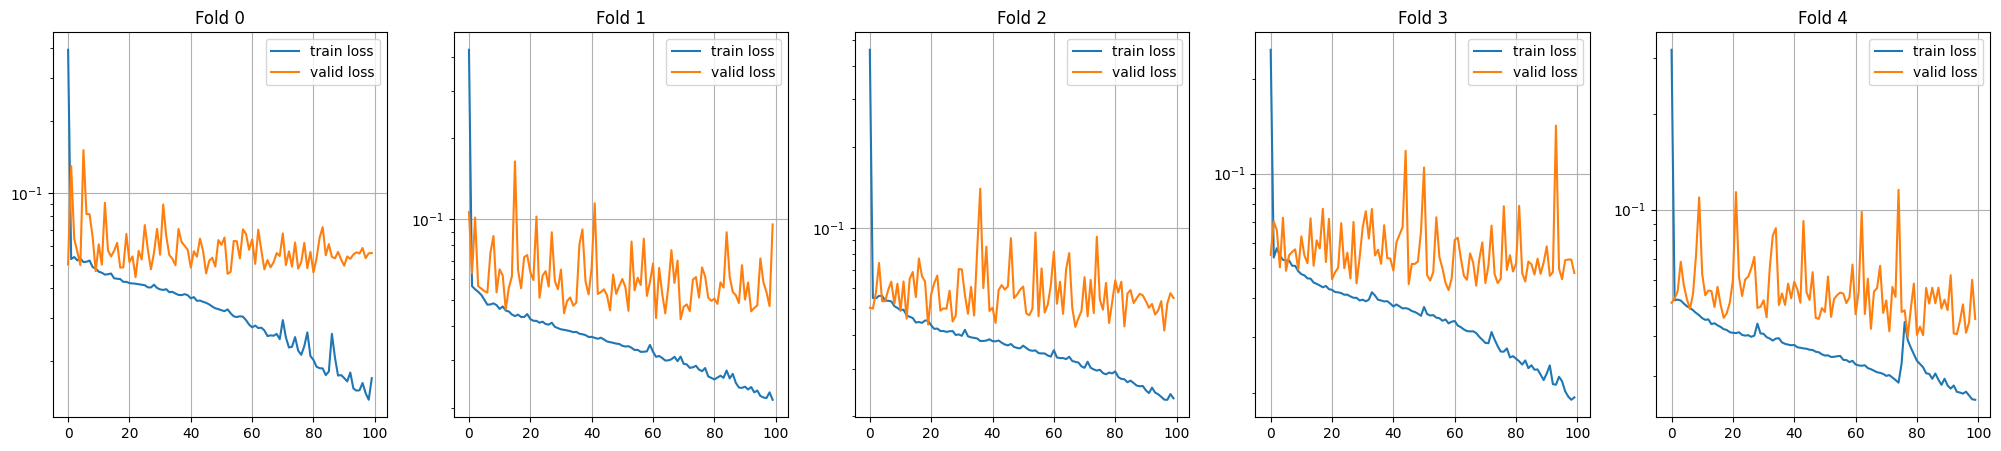

Axis 2, Fold 0:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/100 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/100 [00:00<?, ?it/s]

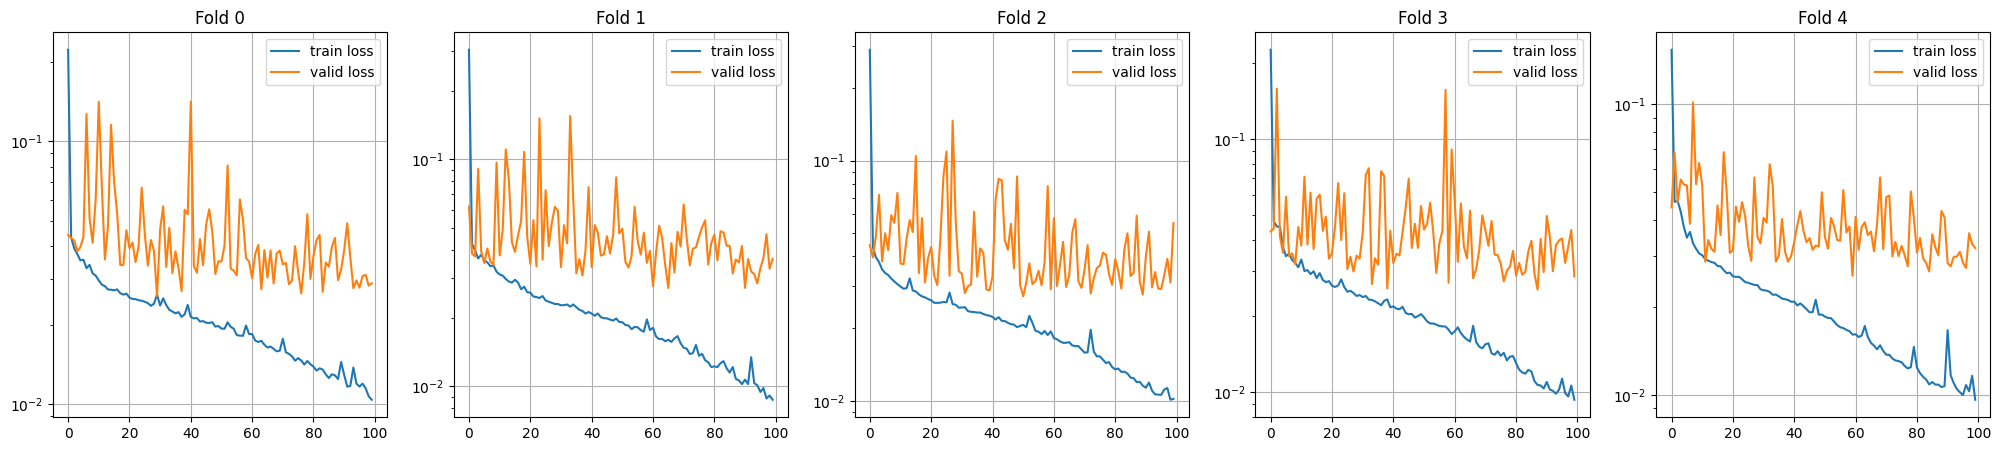

In [9]:
batch_size = 128
epochs = 100
learning_rate = 10e-3
num_splits = 5
num_workers = 12
outdir = "../models/SmallResNed_v2"

if not os.path.isdir(outdir):
    os.mkdir(outdir)

for axis in range(num_axis):
    history = []
    dataset = CustomDataset(X, y, v_axis=axis)
    skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=42)
    for fold, (train_idx, valid_idx) in enumerate(skf.split(X, dummy_y)):
        train_dataset = Subset(dataset, train_idx)
        valid_dataset = Subset(dataset, valid_idx)
        train_loader = DataLoader(
            train_dataset,
            batch_size=batch_size,
            num_workers=num_workers,
            shuffle=True
        )
        valid_loader = DataLoader(
            valid_dataset,
            batch_size=batch_size,
            num_workers=num_workers,
            shuffle=False
        )
        model, loss_fn, optimizer = build_model(learning_rate)
        
        model.to(device)
        history_1epoch = {"train": [], "valid": []}
        best_value = 10e9
        best_epoch = 0
        pbar = tqdm(total=epochs, desc=f"Axis {axis}, Fold {fold}")
        for epoch in range(epochs):
            model.train()
            train_loss = train_1epoch(model, loss_fn, optimizer, train_loader)
            model.eval()
            valid_loss = valid_1epoch(model, loss_fn, valid_loader)
            
            history_1epoch["train"].append(train_loss)
            history_1epoch["valid"].append(valid_loss)
            
            if valid_loss < best_value:
                torch.save(model, os.path.join(outdir, f"Axis{axis}_Fold{fold}_BestEpoch.pt"))
                best_value = valid_loss
                best_epoch = epoch
                
            pbar.set_postfix(OrderedDict(train=train_loss, valid=valid_loss, best=best_value, epoch=best_epoch))
            pbar.update()
        pbar.close()
        history.append(history_1epoch)
        
        torch.save(model, os.path.join(outdir, f"Axis{axis}_Fold{fold}_FinalEpoch.pt"))
        
        # print("=======================================")
        # print(f"  Best epoch: {best_epoch}, valid loss: {best_value:.5f}")
        # print("=======================================")
    
    fig = plt.figure(figsize=(5*num_splits, 5))
    for i in range(num_splits):
        ax = fig.add_subplot(1, num_splits, i+1)
        ax.plot(history[i]["train"], label="train loss")
        ax.plot(history[i]["valid"], label="valid loss")
        ax.set_title(f"Fold {i}")
        # ax.set_ylim([0.002, 0.5])
        ax.set_yscale("log")
        ax.legend()
        ax.grid()
    plt.savefig(os.path.join(outdir, f"Axis{axis}_LearningCurve.png"), format="png")
    plt.show()

Axis 0, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

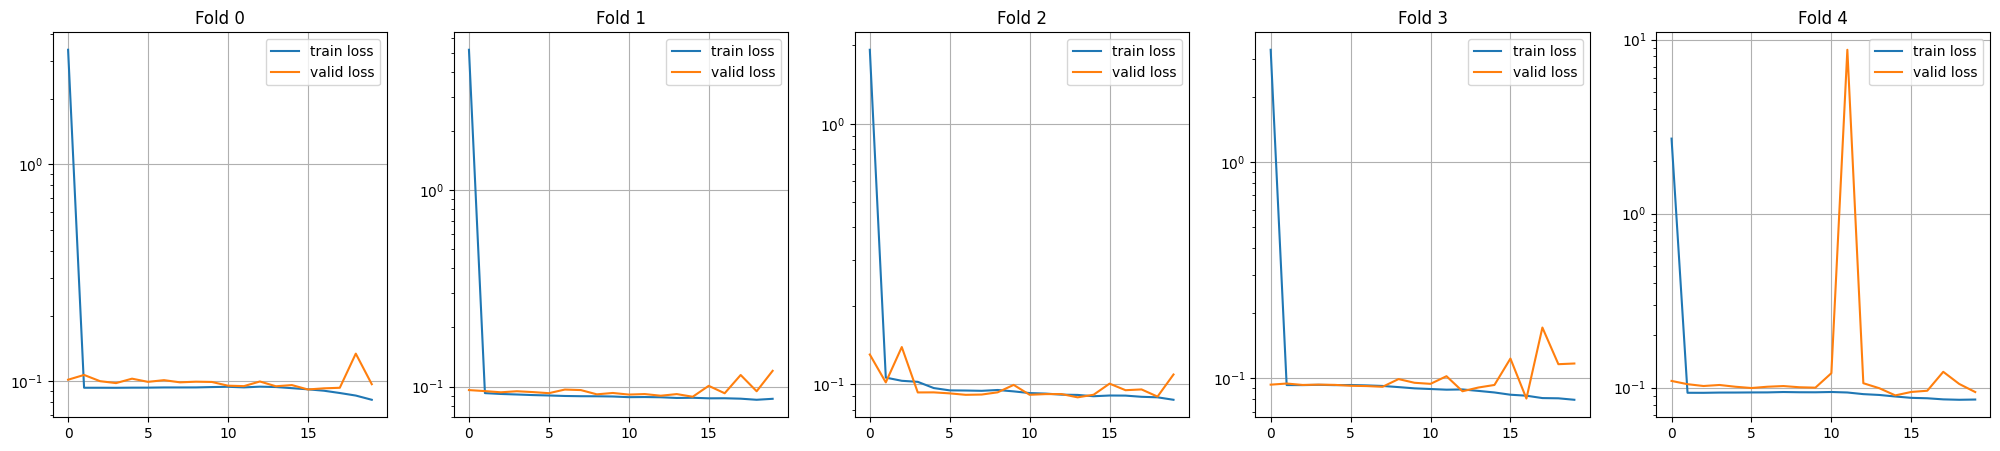

Axis 1, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

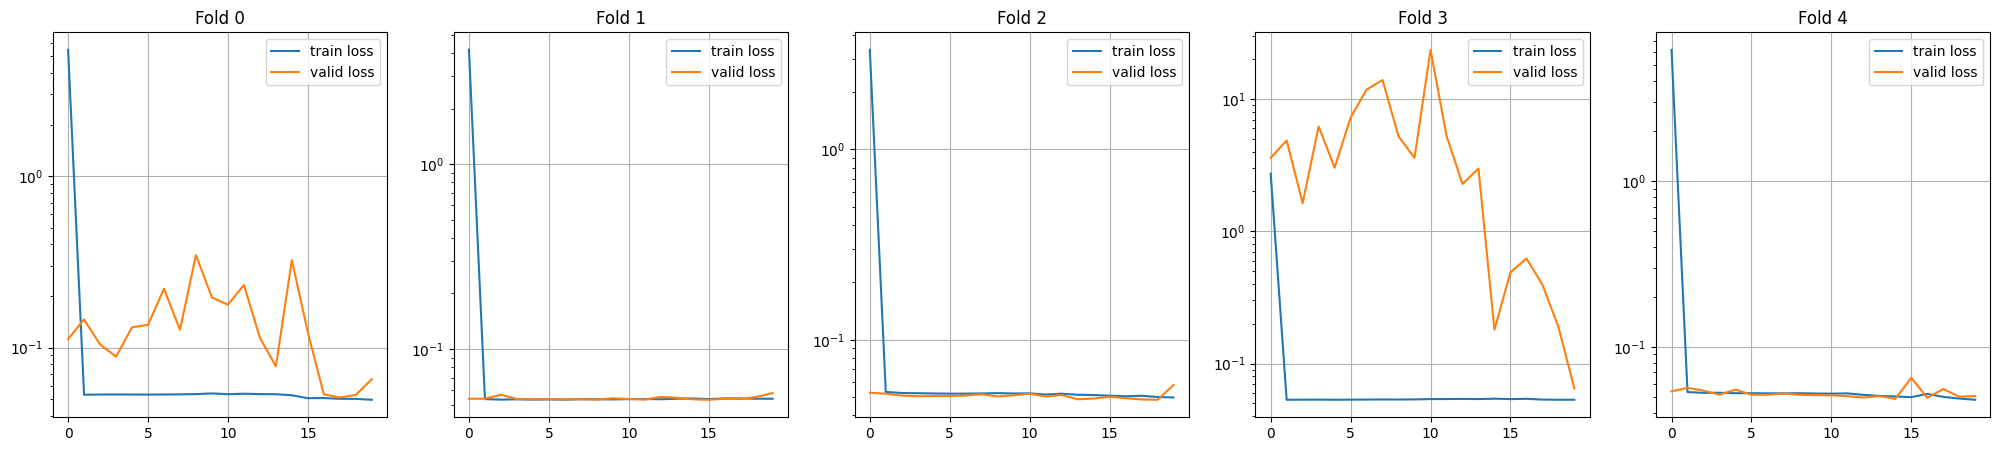

Axis 2, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

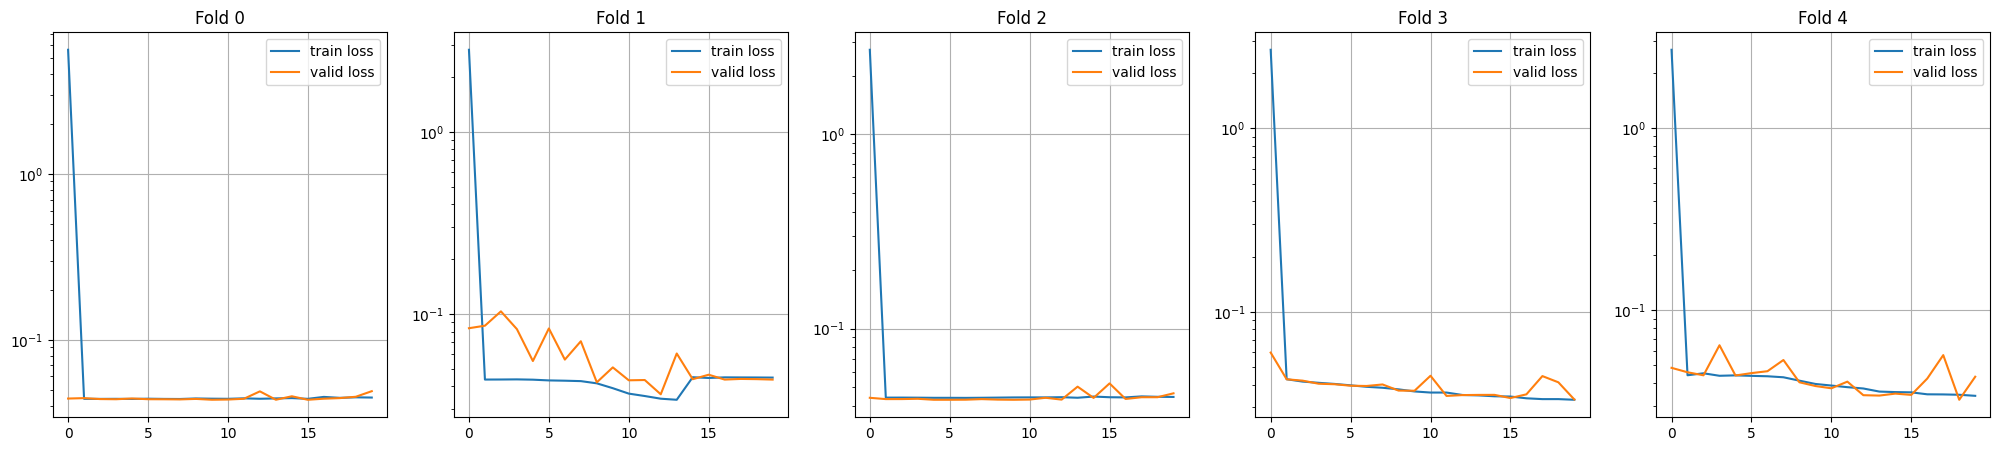

Axis 0, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

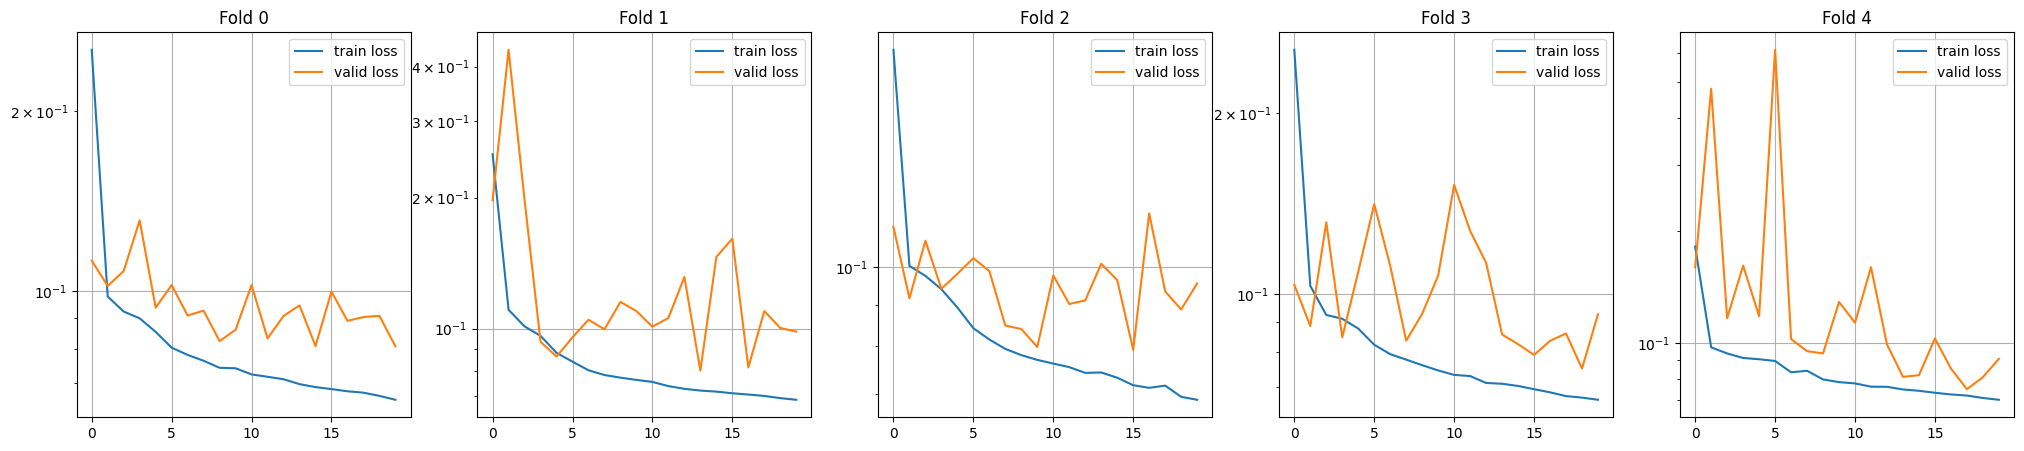

Axis 1, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

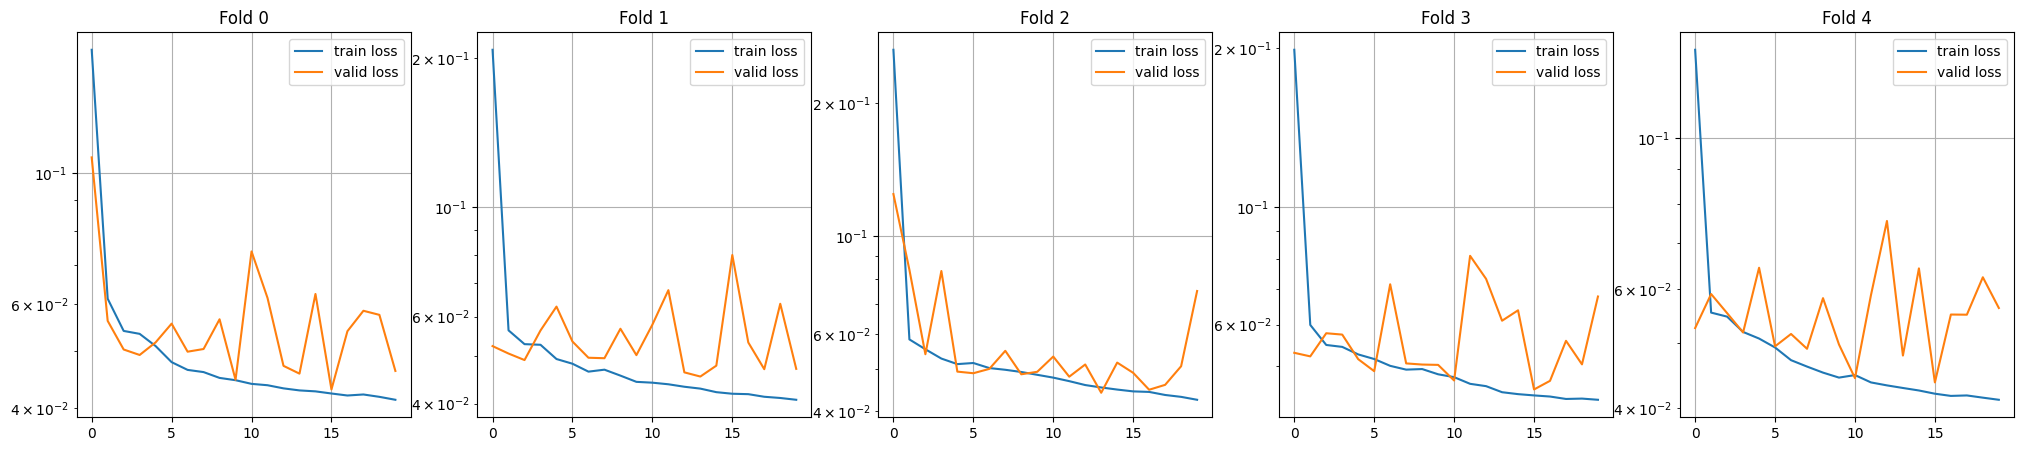

Axis 2, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

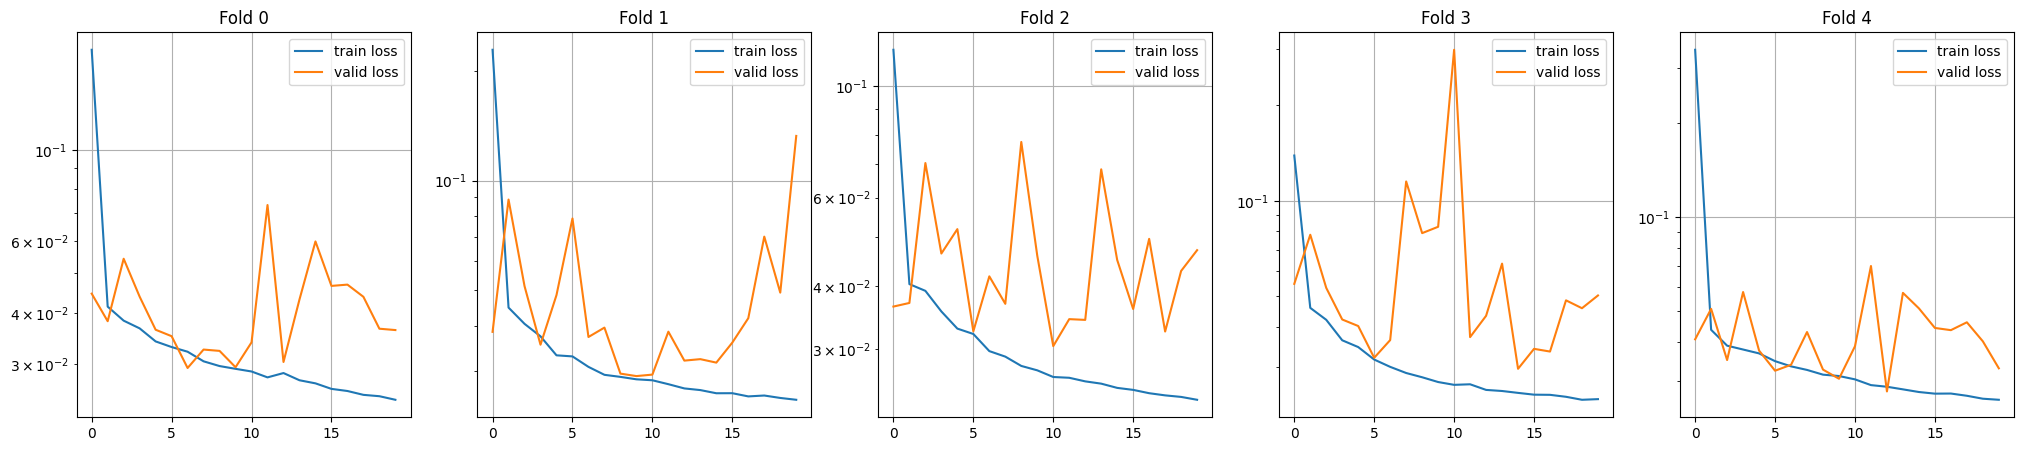

Axis 0, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

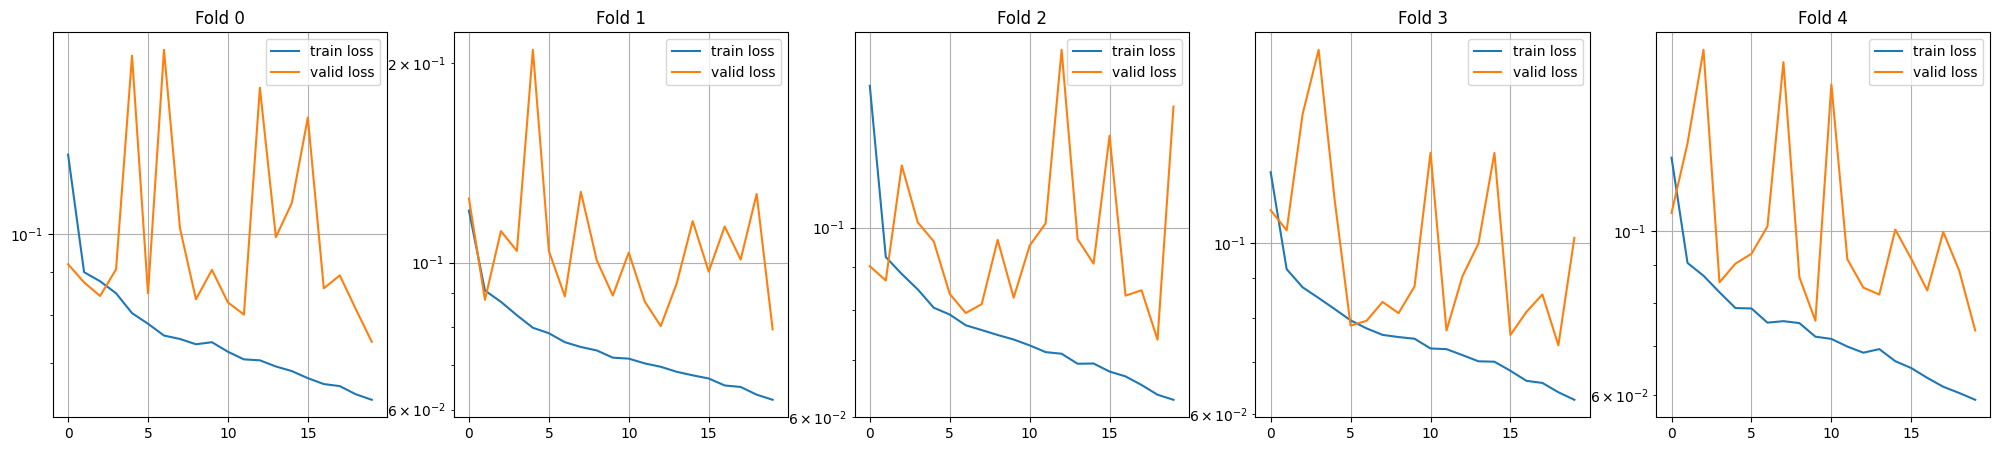

Axis 1, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

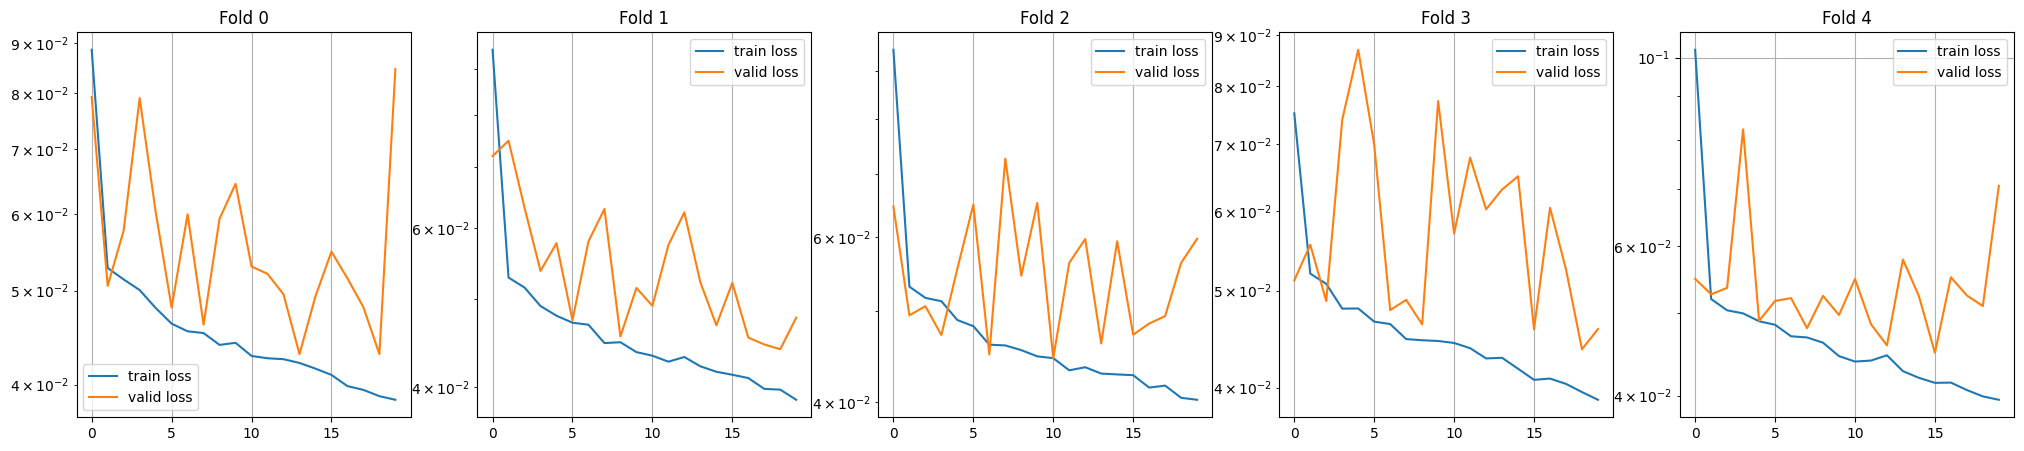

Axis 2, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

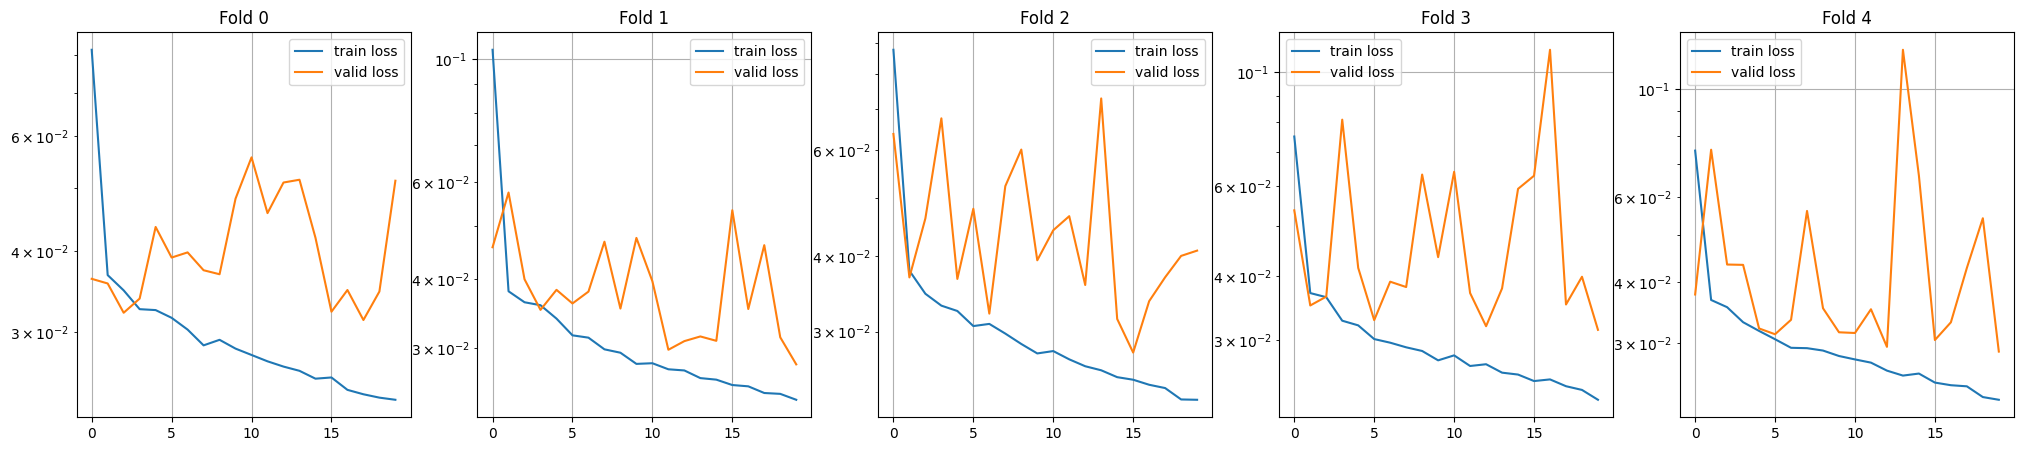

Axis 0, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

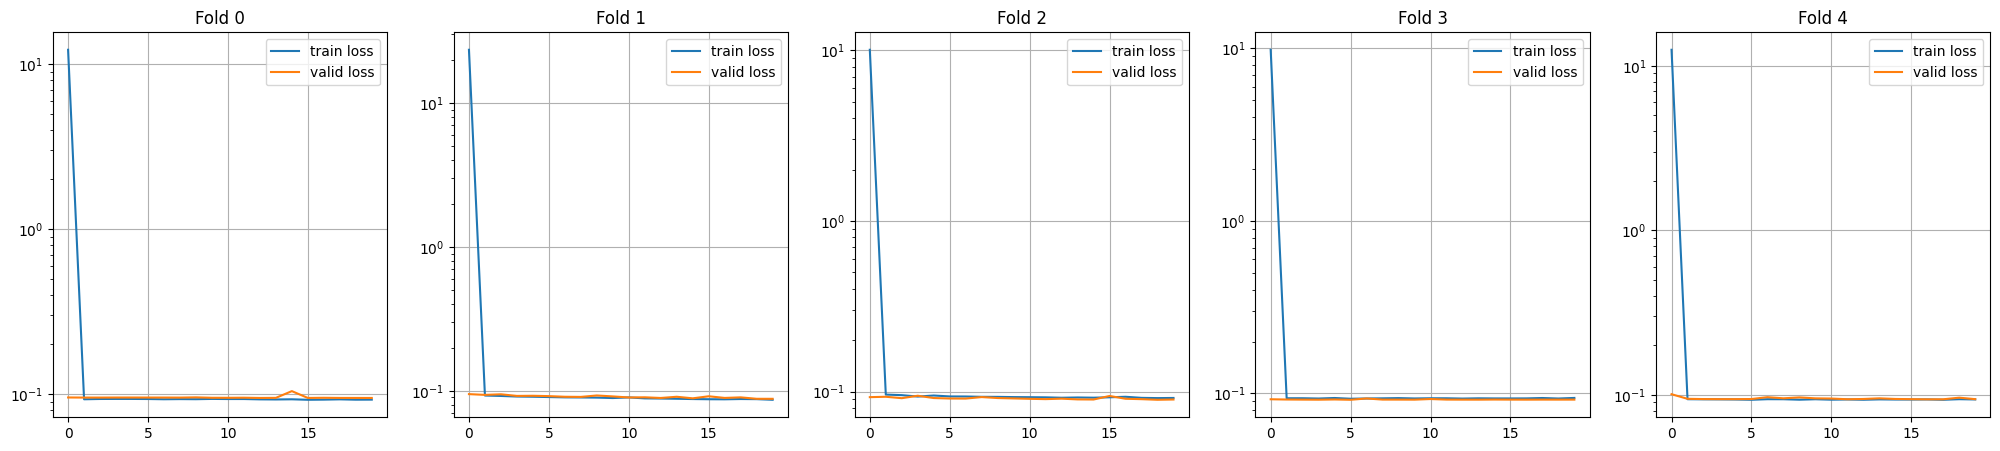

Axis 1, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

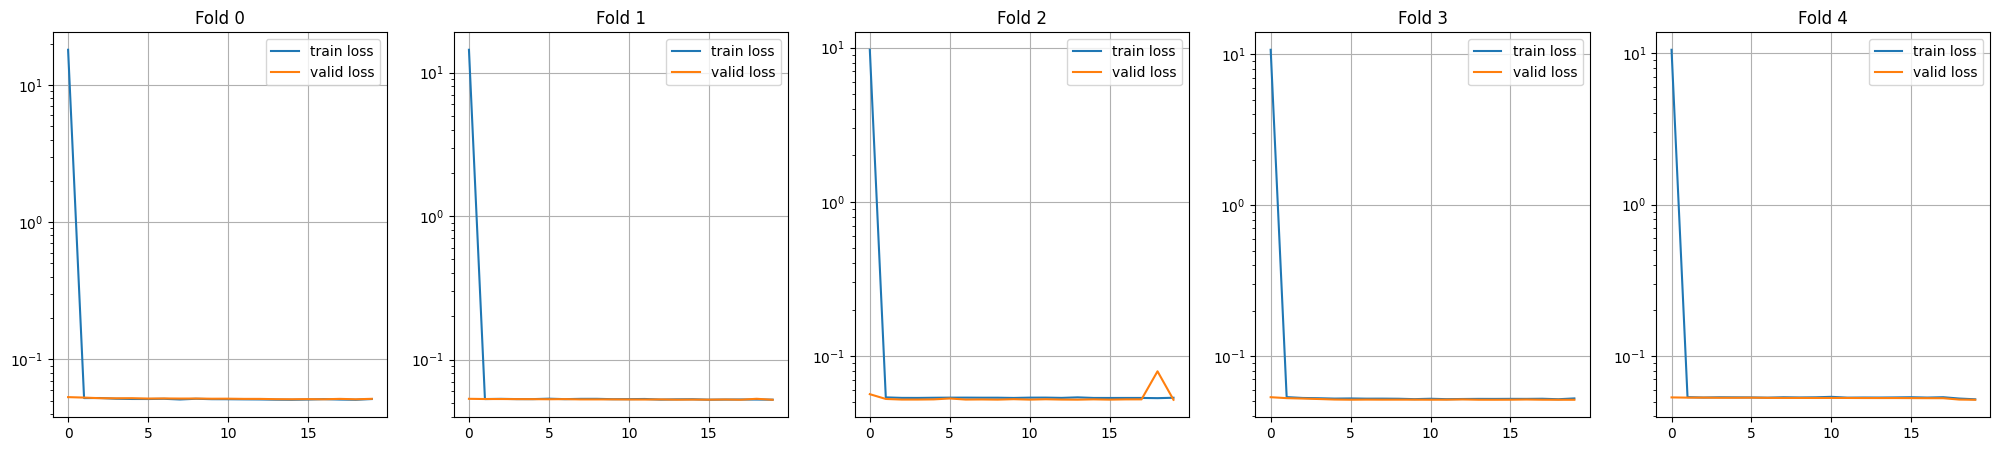

Axis 2, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

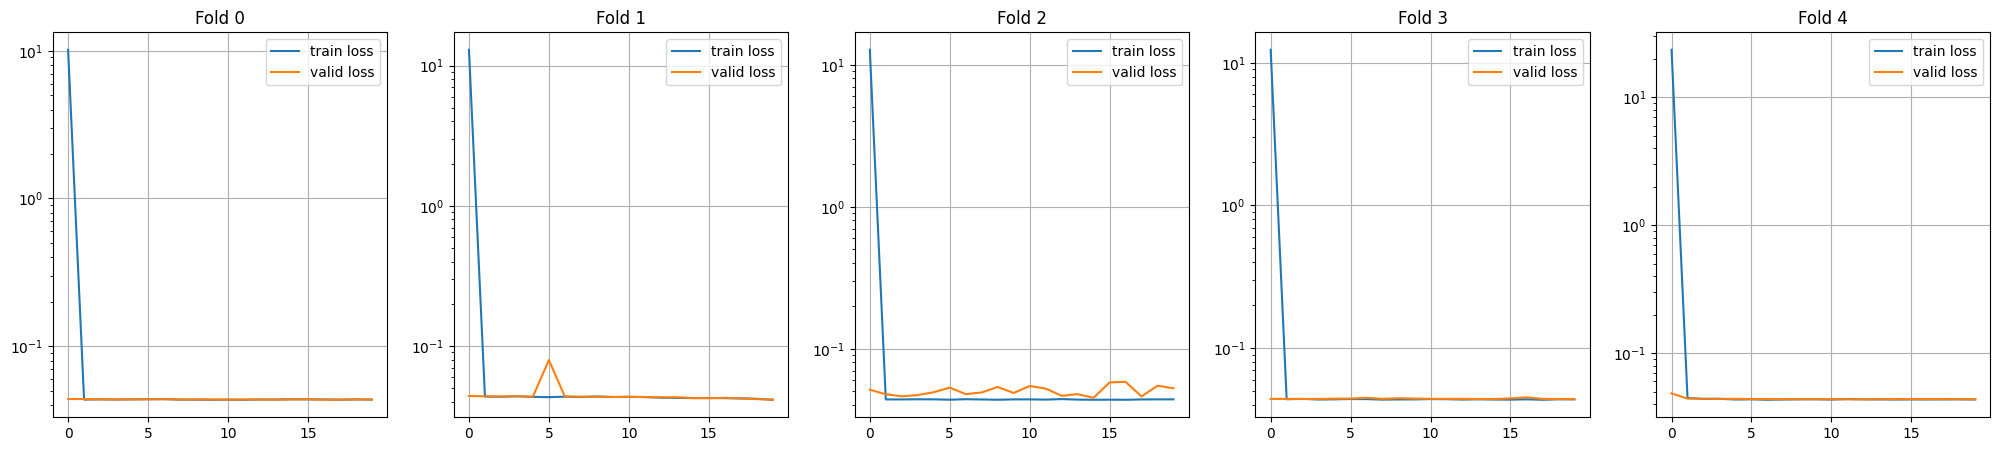

Axis 0, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

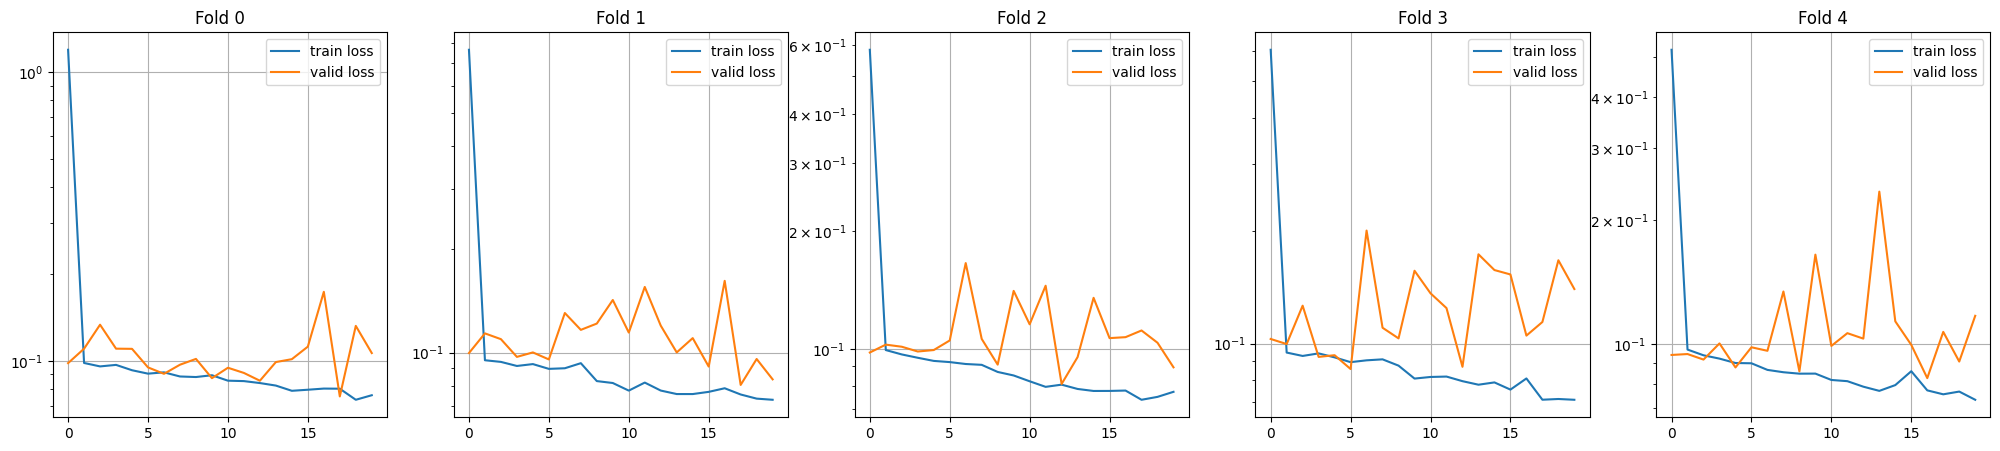

Axis 1, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

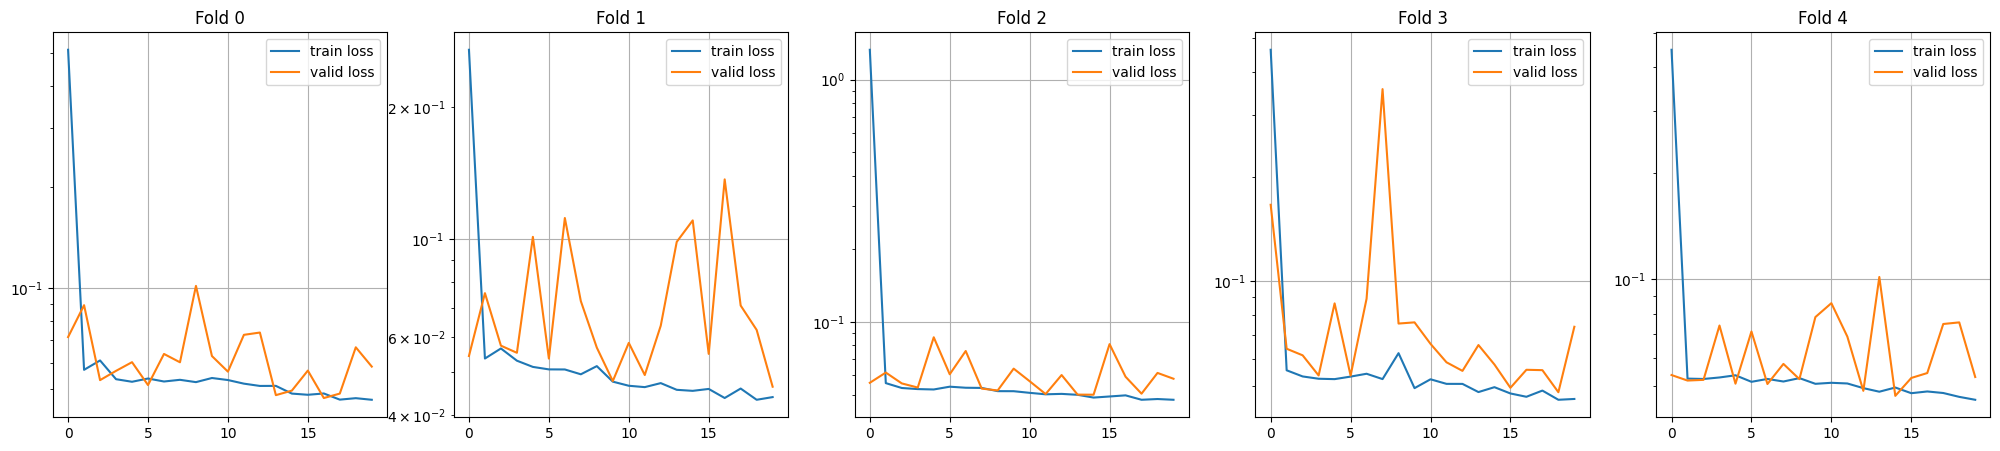

Axis 2, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

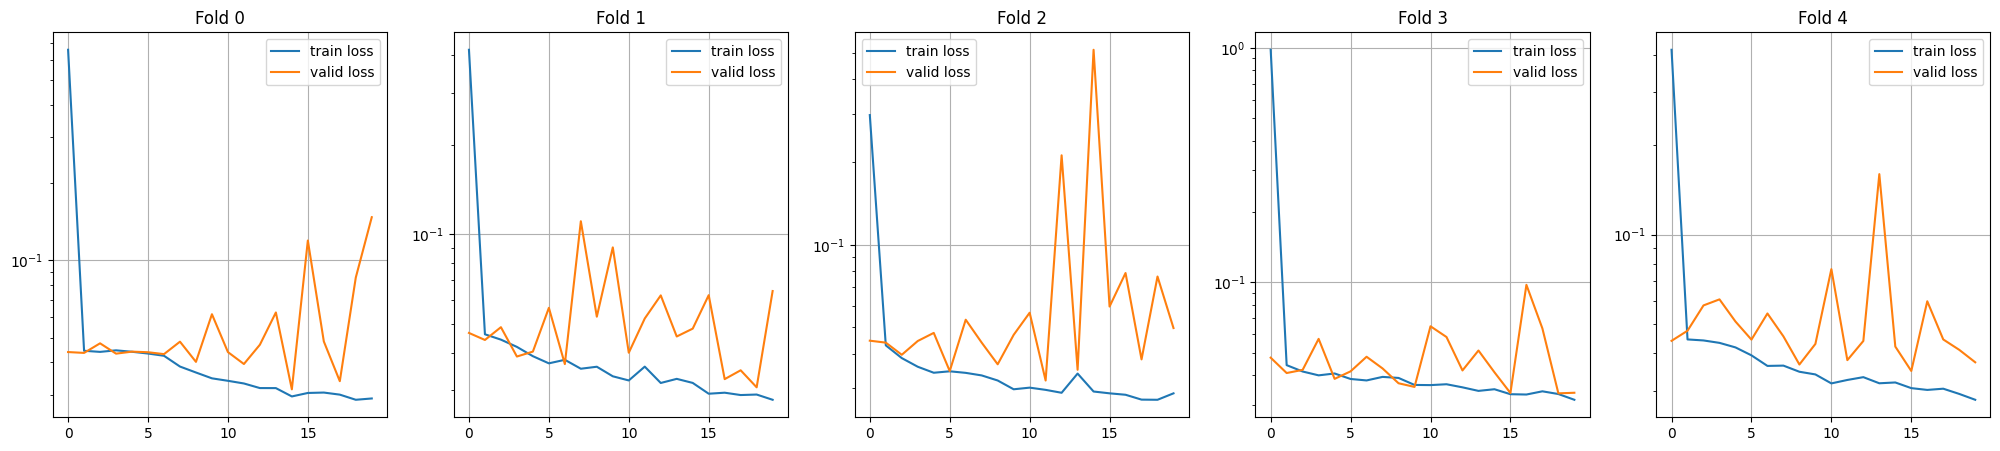

Axis 0, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

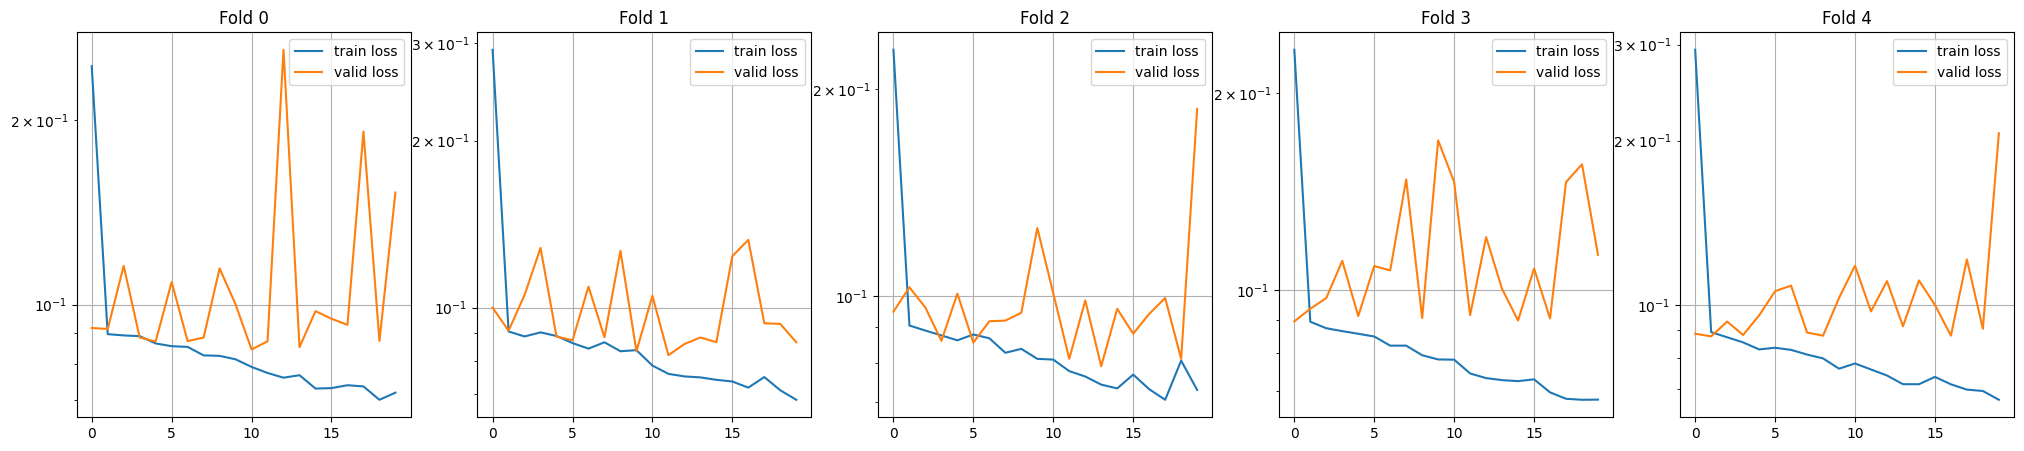

Axis 1, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

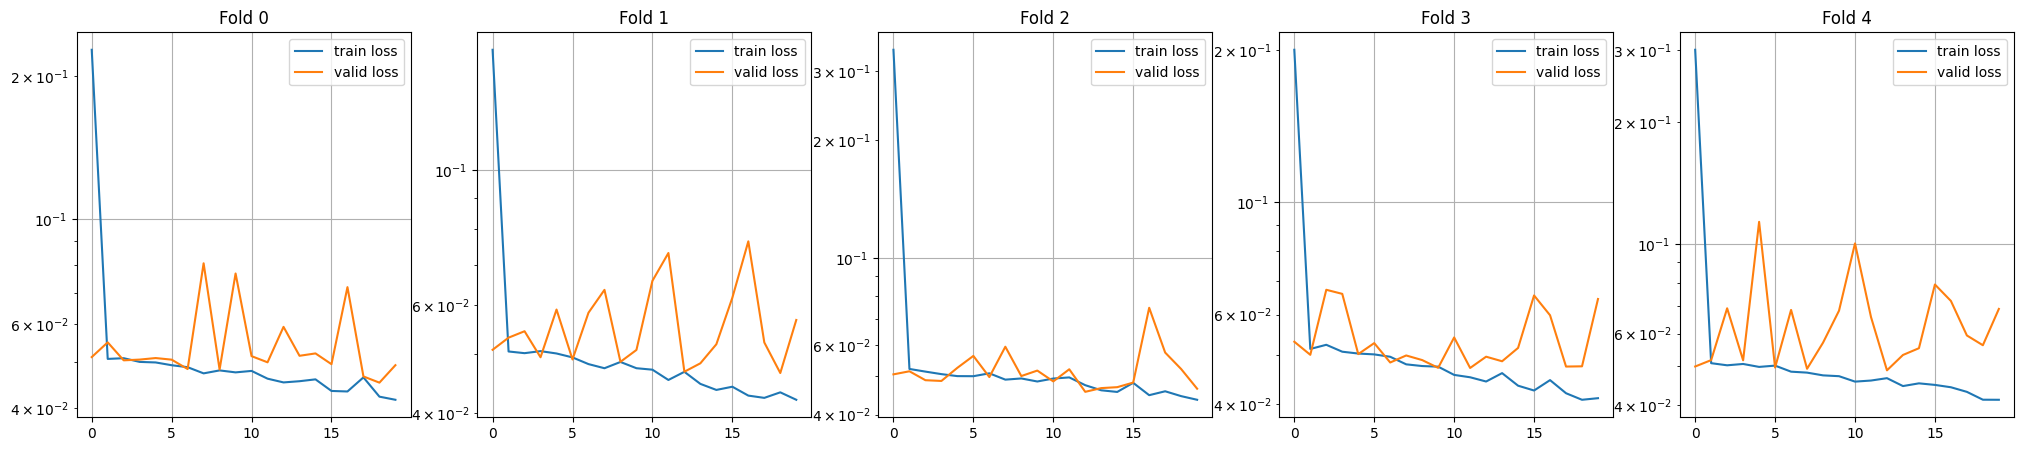

Axis 2, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

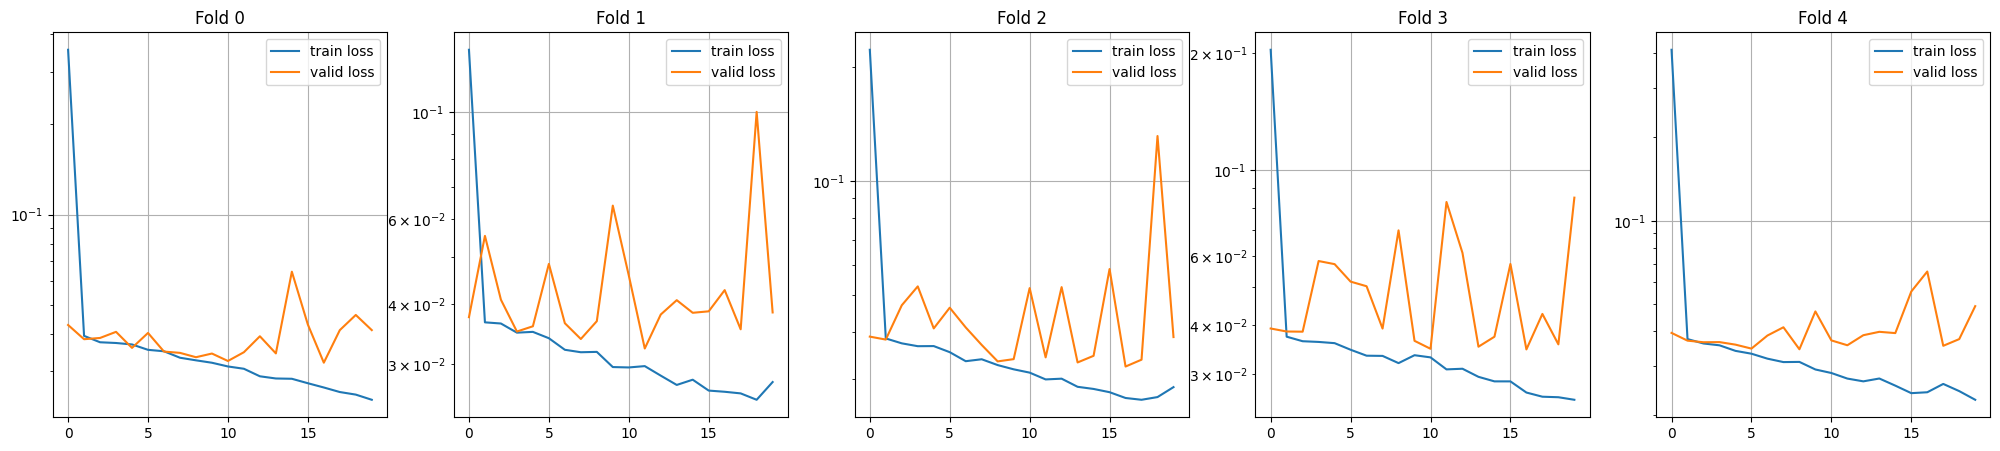

Axis 0, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

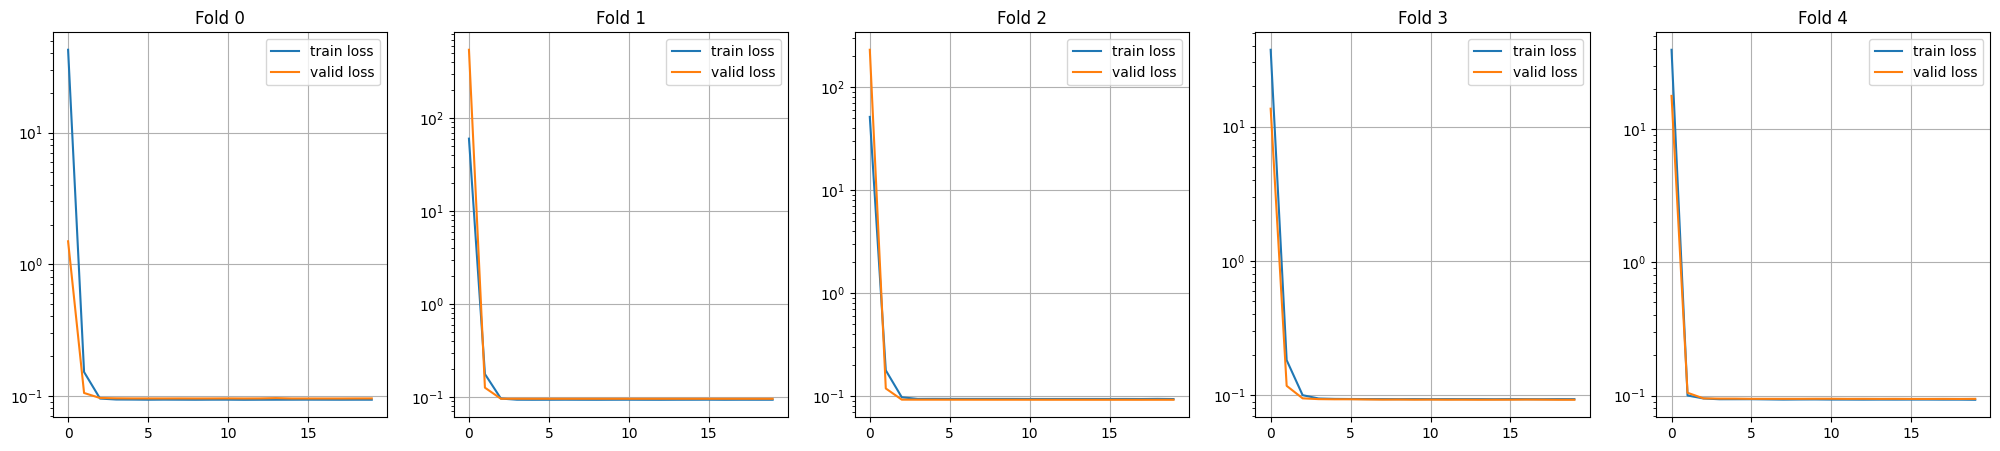

Axis 1, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

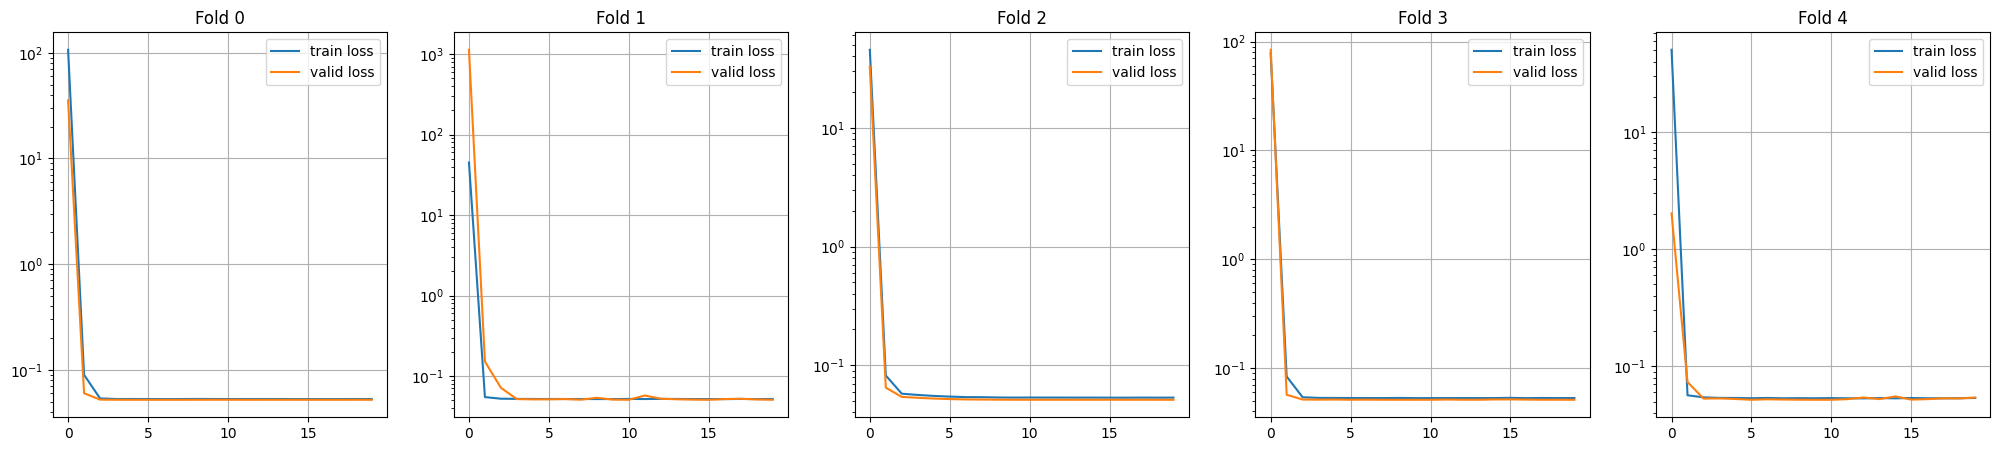

Axis 2, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

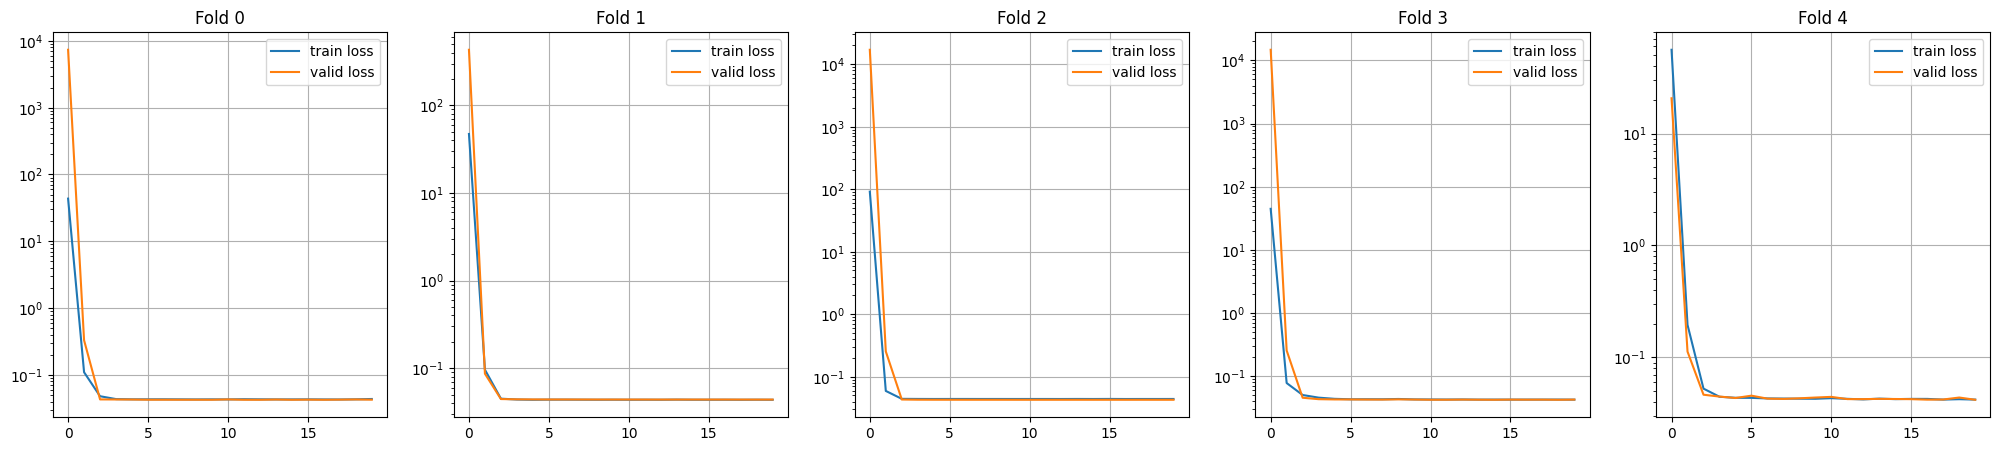

Axis 0, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

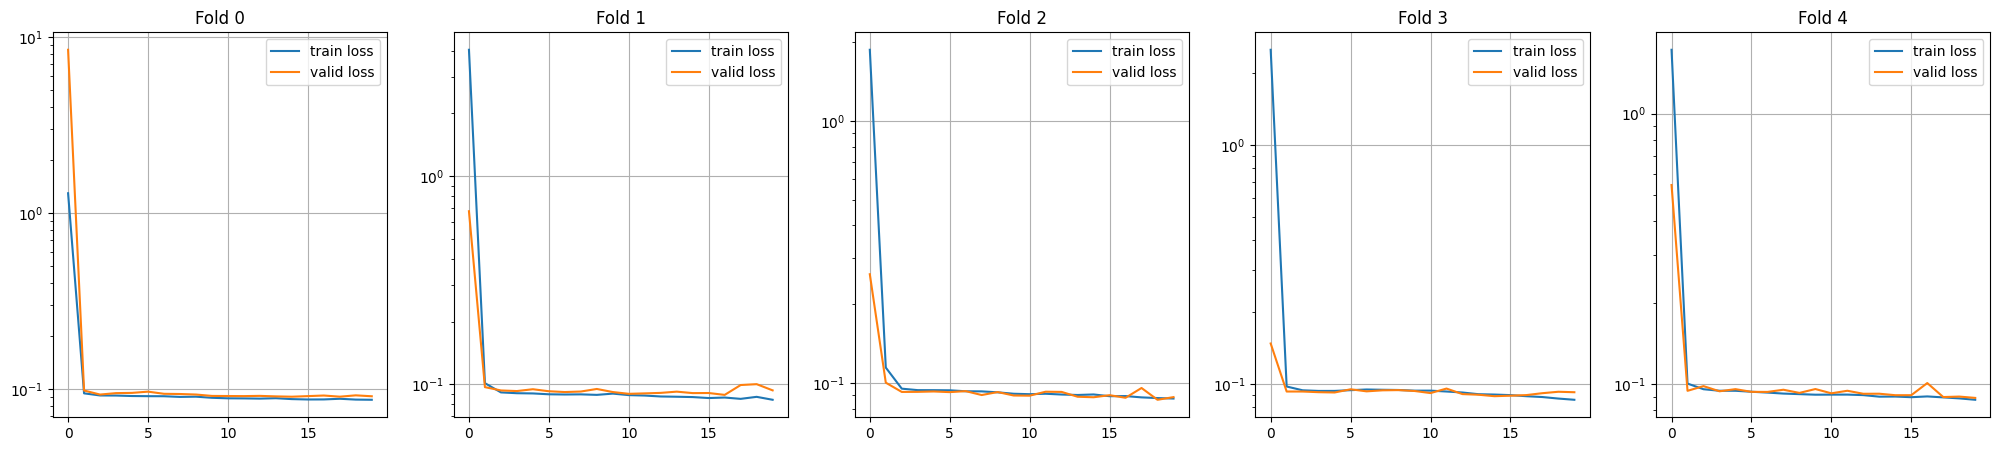

Axis 1, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

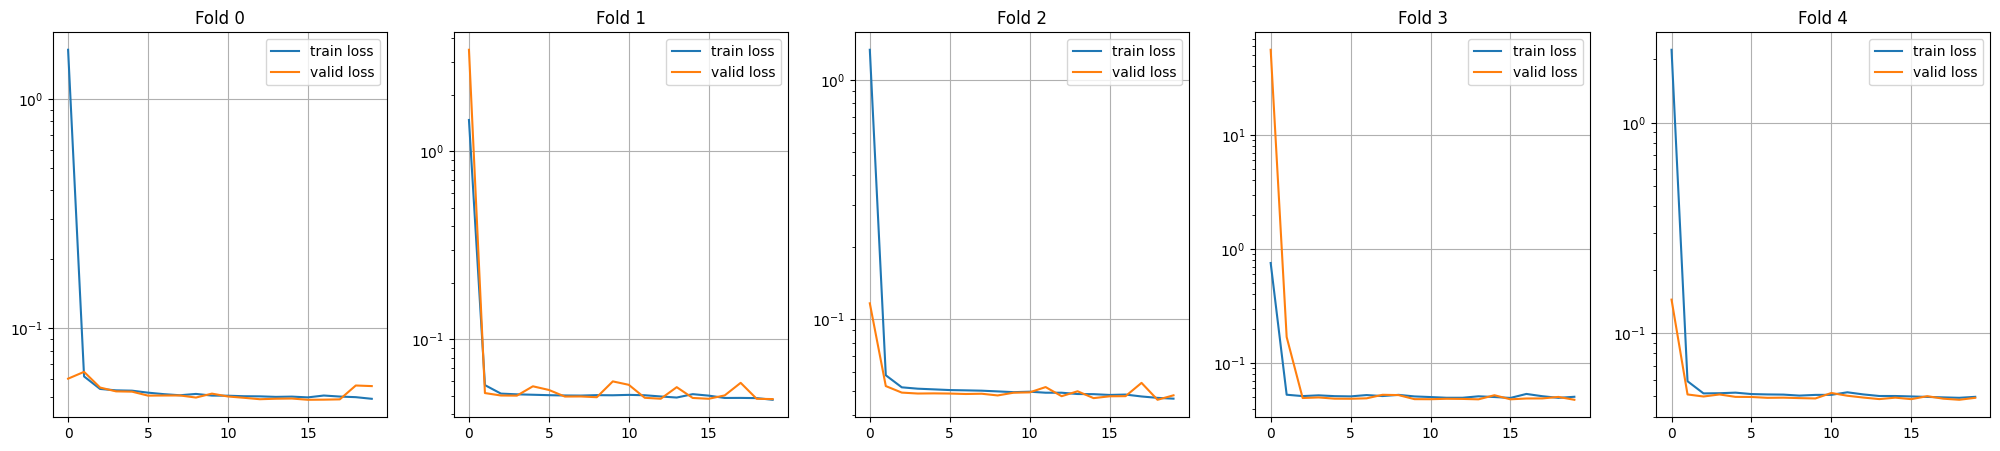

Axis 2, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

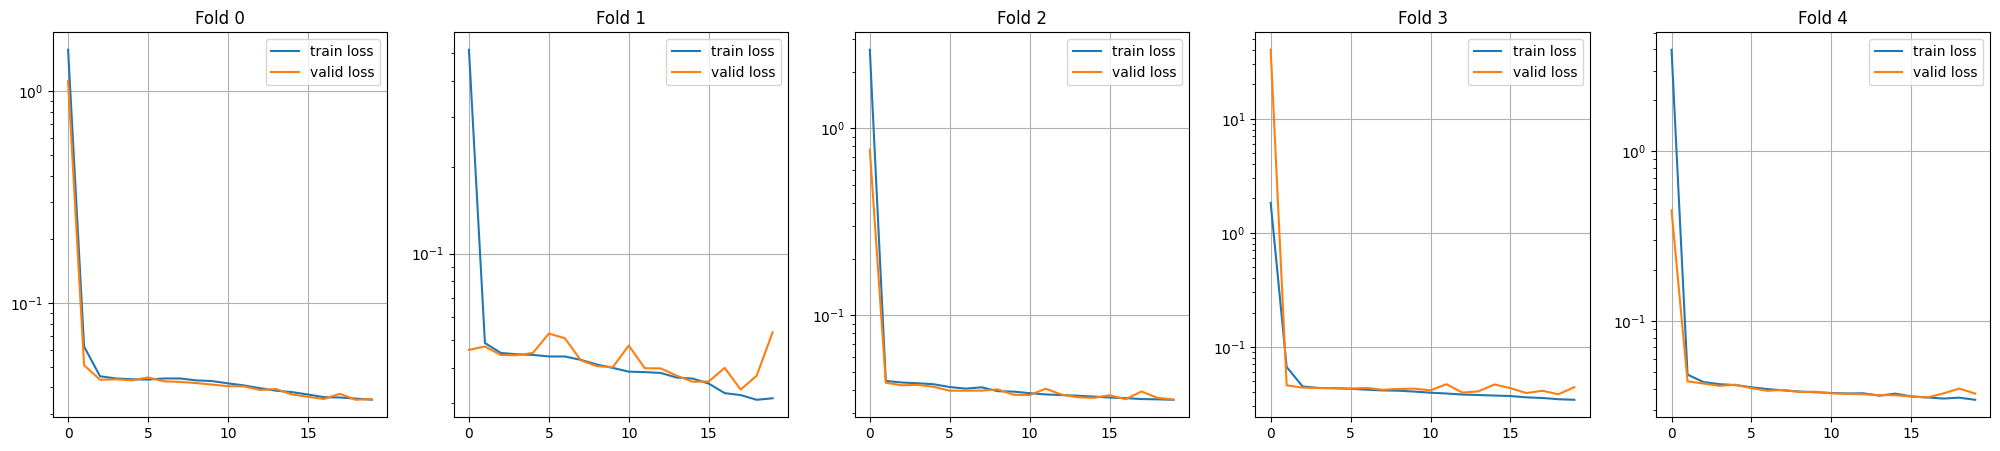

Axis 0, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 0, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

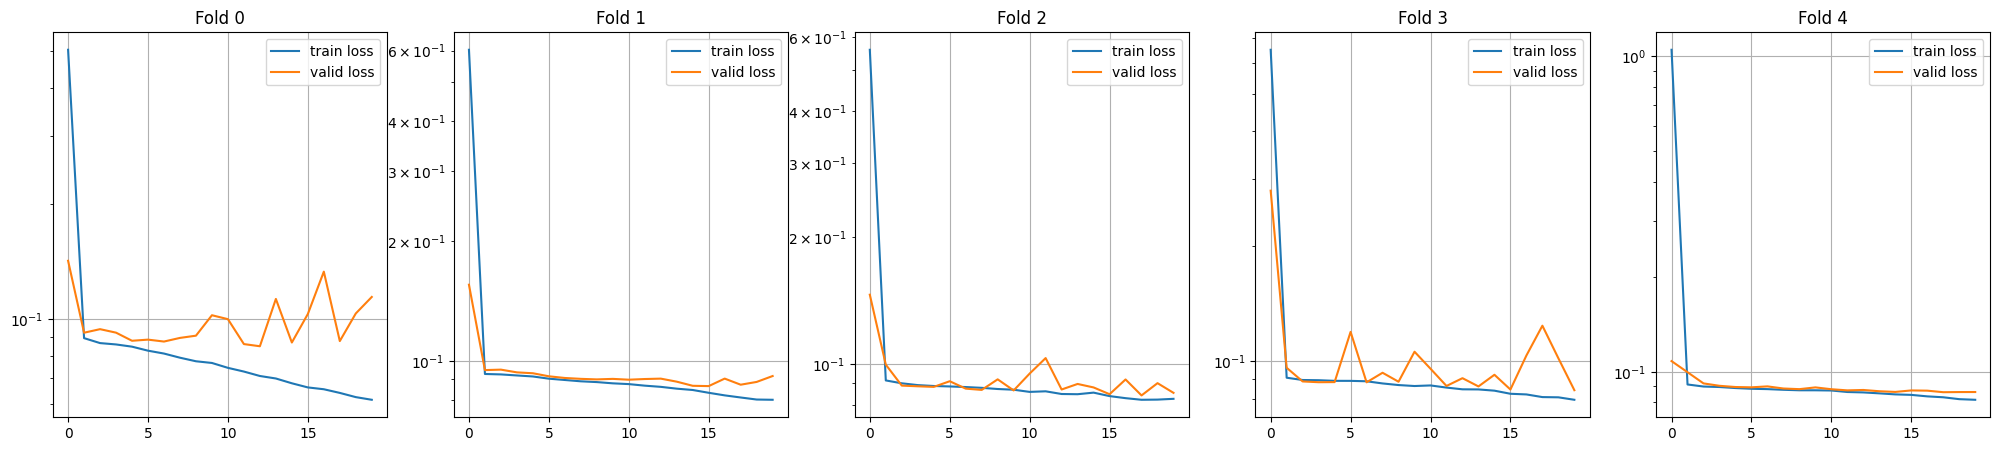

Axis 1, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 1, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

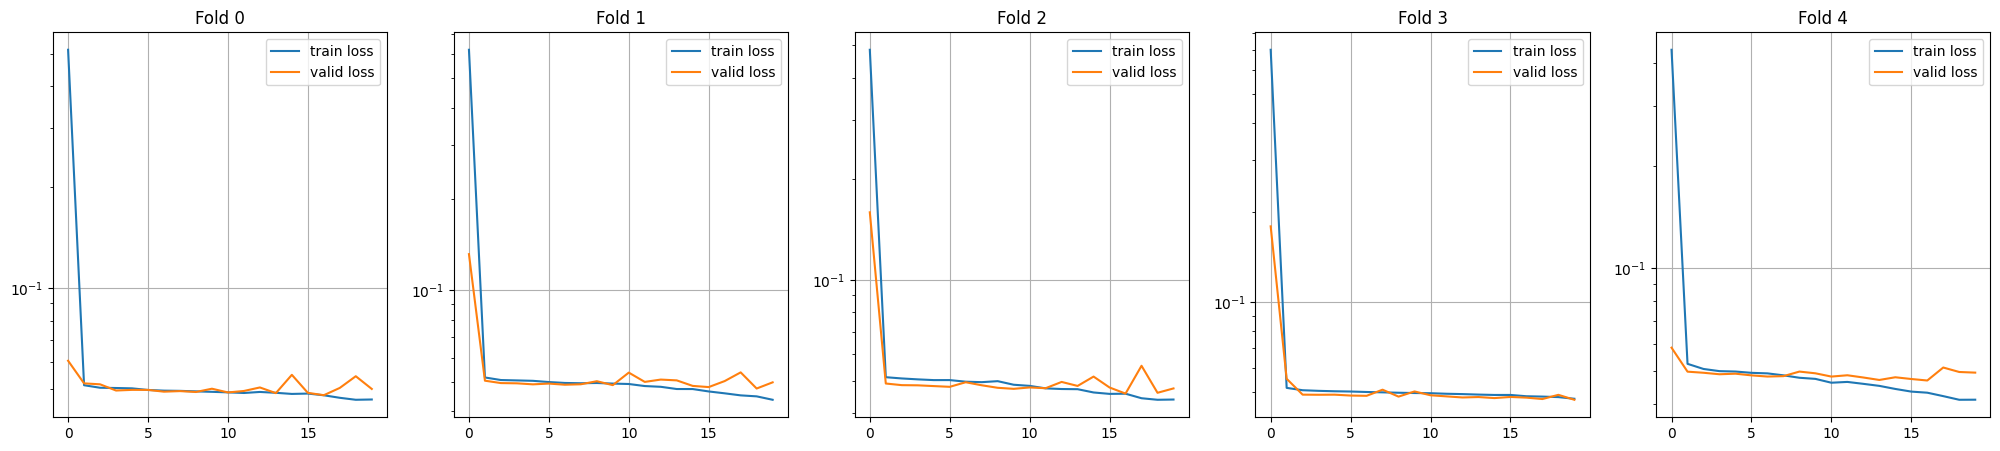

Axis 2, Fold 0:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 1:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 2:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 3:   0%|          | 0/20 [00:00<?, ?it/s]

Axis 2, Fold 4:   0%|          | 0/20 [00:00<?, ?it/s]

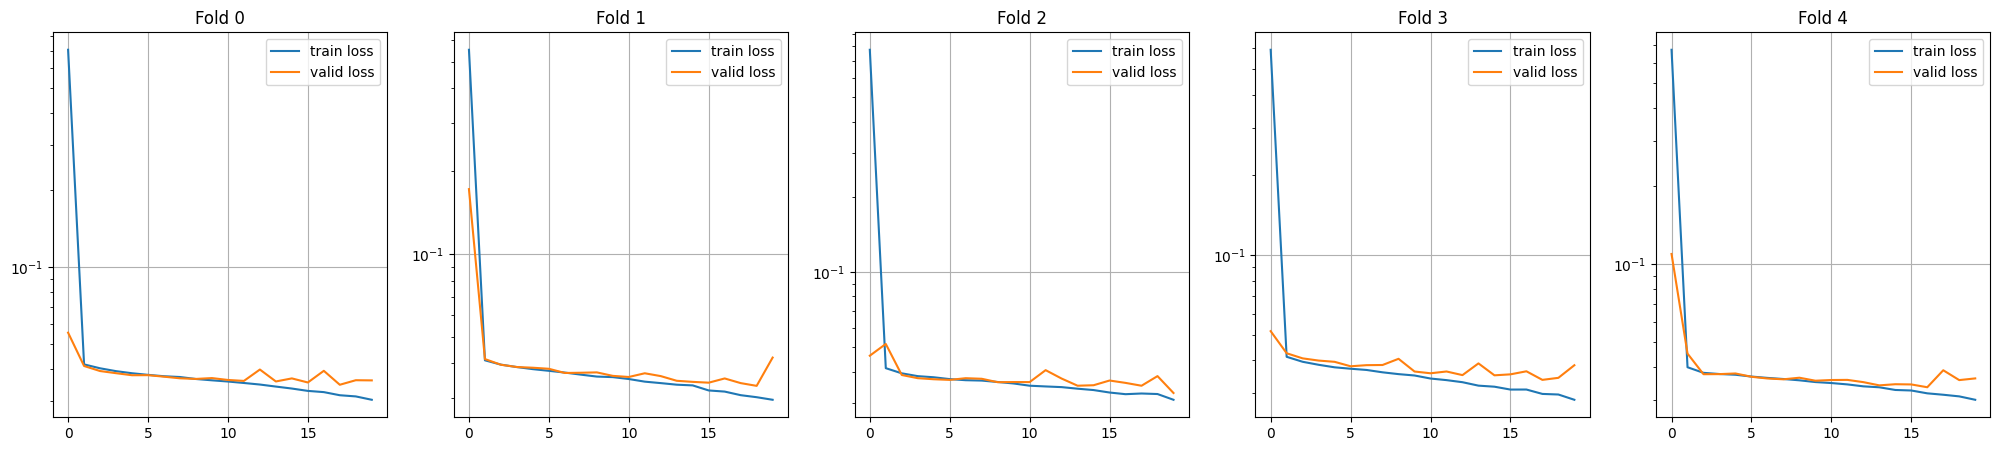

In [12]:
batch_size = 30
epochs = 50
learning_rate = 10e-5
num_splits = 5
num_workers = 12
outdir = "../models/SmallResNet_v2_Batch256_Epoch50_lr10e5"


def train(batch_size, epochs, learning_rate, num_splits, num_workers, outdir):
    if not os.path.isdir(outdir):
        os.mkdir(outdir)

    for axis in range(num_axis):
        history = []
        dataset = CustomDataset(X, y, v_axis=axis)
        skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=42)
        for fold, (train_idx, valid_idx) in enumerate(skf.split(X, dummy_y)):
            train_dataset = Subset(dataset, train_idx)
            valid_dataset = Subset(dataset, valid_idx)
            train_loader = DataLoader(
                train_dataset,
                batch_size=batch_size,
                num_workers=num_workers,
                shuffle=True
            )
            valid_loader = DataLoader(
                valid_dataset,
                batch_size=batch_size,
                num_workers=num_workers,
                shuffle=False
            )
            model, loss_fn, optimizer = build_model(learning_rate)
            
            model.to(device)
            history_1epoch = {"train": [], "valid": []}
            best_value = 10e9
            best_epoch = 0
            pbar = tqdm(total=epochs, desc=f"Axis {axis}, Fold {fold}")
            for epoch in range(epochs):
                model.train()
                train_loss = train_1epoch(model, loss_fn, optimizer, train_loader)
                model.eval()
                valid_loss = valid_1epoch(model, loss_fn, valid_loader)
                
                history_1epoch["train"].append(train_loss)
                history_1epoch["valid"].append(valid_loss)
                
                if valid_loss < best_value:
                    torch.save(model, os.path.join(outdir, f"Axis{axis}_Fold{fold}_BestEpoch.pt"))
                    best_value = valid_loss
                    best_epoch = epoch
                    
                pbar.set_postfix(OrderedDict(train=train_loss, valid=valid_loss, best=best_value, epoch=best_epoch))
                pbar.update()
            pbar.close()
            history.append(history_1epoch)
            
            torch.save(model, os.path.join(outdir, f"Axis{axis}_Fold{fold}_FinalEpoch.pt"))
            
            # print("=======================================")
            # print(f"  Best epoch: {best_epoch}, valid loss: {best_value:.5f}")
            # print("=======================================")
        
        fig = plt.figure(figsize=(5*num_splits, 5))
        for i in range(num_splits):
            ax = fig.add_subplot(1, num_splits, i+1)
            ax.plot(history[i]["train"], label="train loss")
            ax.plot(history[i]["valid"], label="valid loss")
            ax.set_title(f"Fold {i}")
            # ax.set_ylim([0.002, 0.5])
            ax.set_yscale("log")
            ax.legend()
            ax.grid()
        plt.savefig(os.path.join(outdir, f"Axis{axis}_LearningCurve.png"), format="png")
        plt.show()

def grid_search():
    params = {
        "batch_size": [64, 256, 1024],
        "learning_rate": [10e-2, 10e-3, 10e-4],
    }
    epochs = 20
    num_splits = 5
    for batch_size in params["batch_size"]:
        for learning_rate in params["learning_rate"]:
            outdir = f"../models/ResNet_v2_GridSearch_Batch{batch_size}_lr{learning_rate}"
            train(batch_size, epochs, learning_rate, num_splits, num_workers, outdir)

grid_search()